# A CAM physics routine as a function

`cldwat2m_macro::mmacro_pcond` is the single-column condensation routine at
the core of CAM5's cloud macrophysics.  In the model it runs inside a
timestep on a chunk of columns, fed from the physics buffer by
`macrop_driver_tend`.  Here it is a function: one vertical column in, that
column's outputs back, the original Fortran doing the arithmetic.

There is no `fc.Driver`, no MPI session, no global field and no
Driver-managed model state.  The routine is linked from the model build's
own objects into a small standalone image that runs in a worker process
beside this notebook; the few module-level constants the routine reads are
initialized there from a snapshot of a real run and verified bit for bit.

Five parts: load the function, read its signature, call it by hand, define
a sampling space over inputs and parameters, generate and save training
data.  An appendix shows what happens when the routine refuses an input.

## 1. Load the function

In [1]:
import numpy as np
import freecam as fc

scheme = fc.physics.load_function("mmacro_pcond")
scheme

PhysicsFunction('cldwat2m_macro::mmacro_pcond', host=SubprocessHost)

## 2. The signature

Inputs are one column: `[lev]` profiles and scalars.  In/out arguments take
an initial value and come back updated.  Parameters are the routine's own
namelist tunables; each is an extra dimension a surrogate can learn.  The
timestep `dt` is an input because the tendencies scale with it.

In [2]:
print(scheme.describe())

cldwat2m_macro::mmacro_pcond  (components/cam/src/physics/cam/cldwat2m_macro.F90)

Inputs:
  dt             scalar        s  default=1800.0
  p              [lev]         Pa
  dp             [lev]         Pa
  a_t            [lev]         K/s  default=0.0
  a_qv           [lev]         kg/kg/s  default=0.0
  a_ql           [lev]         kg/kg/s  default=0.0
  a_qi           [lev]         kg/kg/s  default=0.0
  a_nl           [lev]         #/kg/s  default=0.0
  a_ni           [lev]         #/kg/s  default=0.0
  c_t            [lev]         K/s  default=0.0
  c_qv           [lev]         kg/kg/s  default=0.0
  c_ql           [lev]         kg/kg/s  default=0.0
  c_qi           [lev]         kg/kg/s  default=0.0
  c_nl           [lev]         #/kg/s  default=0.0
  c_ni           [lev]         #/kg/s  default=0.0
  c_qlst         [lev]         kg/kg/s  default=0.0
  d_t            [lev]         K/s  default=0.0
  d_qv           [lev]         kg/kg/s  default=0.0
  d_ql           [lev]      

## 3. Call it by hand

A real column makes the best starting point.  `example_input` ships one
captured at the routine's own call site in a 512-rank run, with the surface
pressure and hybrid coordinate of that run.  It is a plain mapping of
inputs, so change any value and call again; every call is independent.

In [3]:
column = scheme.example_input("captured-anchor")
column

ExampleColumn('captured-anchor' for mmacro_pcond: 35 inputs, surface_pressure=96082.1 Pa, one chunk column captured at the routine's real call site in a 512-rank PI-atm run)

In [4]:
baseline = scheme.run(inputs=column)
baseline

FunctionResult(status='ok', outputs=17, updated_inputs=6)

In [5]:
print("maximum cloud fraction:", np.max(baseline.outputs["cld"]))
print("maximum condensation rate:", np.max(baseline.outputs["qme"]), "kg kg-1 s-1")

# In/out arguments come back updated; the routine adjusts temperature itself.
temperature_change = baseline.updated_inputs["t0"] - column["t0"]
print("maximum temperature update:", np.max(np.abs(temperature_change)), "K")

maximum cloud fraction: 0.0838835291973878
maximum condensation rate: 0.0 kg kg-1 s-1
maximum temperature update: 0.004162222492936962 K


A warmer column with a lower low-cloud RH threshold.  Parameters are
written for this one call and restored afterwards.

In [6]:
warmer = {**column, "t0": column["t0"] + 2.0}
tuned = scheme.run(inputs=warmer, parameters={"cldfrc_rhminl": 0.80})

delta_cld = tuned.outputs["cld"] - baseline.outputs["cld"]
changed_levels = np.flatnonzero(~np.isclose(delta_cld, 0.0, atol=1.0e-12, rtol=0.0)) #|a - b| <= atol + rtol * |b|
print("changed levels:", changed_levels)
print("maximum |Δcld|:", np.max(np.abs(delta_cld)))

changed levels: [21 22 23]
maximum |Δcld|: 0.065889017847566


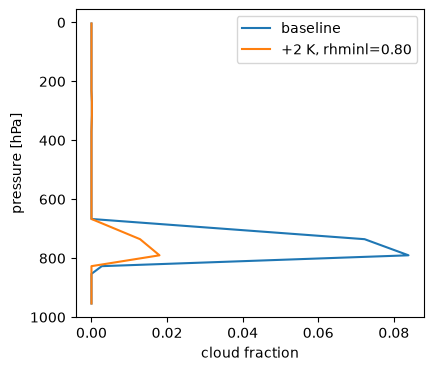

In [7]:
import matplotlib.pyplot as plt

pressure_hpa = column["p"] / 100.0
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(baseline.outputs["cld"], pressure_hpa, label="baseline")
ax.plot(tuned.outputs["cld"], pressure_hpa, label="+2 K, rhminl=0.80")
ax.invert_yaxis()
ax.set_xlabel("cloud fraction")
ax.set_ylabel("pressure [hPa]")
ax.legend()
plt.show()

## 4. A sampling space

Each drawn input or parameter gets a distribution; every input that is not
drawn keeps the example column's value.  Pressure is never drawn level by
level: `HybridPressure` draws one surface pressure and builds the whole
profile through the column's own hybrid coordinate, so `p` and `dp` stay
consistent.  The thermodynamic profiles are anchored on the real column
with bounded noise -- an absolute floor on the cloud species lets a clear
layer become slightly cloudy -- and one parameter joins the space as its
own dimension.

In [8]:
ps = column.surface_pressure
space = scheme.sampling_space(
    base=column,
    inputs={
        "p": fc.physics.HybridPressure.from_column(
            column, surface_pressure=fc.physics.Uniform(0.95 * ps, 1.05 * ps)
        ),
        "t0": fc.physics.Anchored(column["t0"], absolute_scale=1.0),# t0' = t0 + N(0, 1.0)
        "qv0": fc.physics.Anchored(column["qv0"], relative_scale=0.05, absolute_scale=1.0e-8, clip=(0.0, None)), # qv0' = qv0 + qv0 * N(0, 0.05) + N(0,1.0e-8)
        "ql0": fc.physics.Anchored(column["ql0"], relative_scale=0.05, absolute_scale=1.0e-10, clip=(0.0, None)),
        "qi0": fc.physics.Anchored(column["qi0"], relative_scale=0.05, absolute_scale=1.0e-10, clip=(0.0, None)),
    },
    parameters={"cldfrc_rhminl": fc.physics.Uniform(0.80, 0.95)},
)
space

SamplingSpace for mmacro_pcond: 5 drawn inputs, 1 drawn parameters, 29 inputs from the base column
  p                        input      HybridPressure(surface_pressure=Uniform(91278, 100886))
  t0                       input      Anchored(absolute_scale=1.0)
  qv0                      input      Anchored(relative_scale=0.05, absolute_scale=1e-08, clip=(0.0, None))
  ql0                      input      Anchored(relative_scale=0.05, absolute_scale=1e-10, clip=(0.0, None))
  qi0                      input      Anchored(relative_scale=0.05, absolute_scale=1e-10, clip=(0.0, None))
  cldfrc_rhminl            parameter  Uniform(0.8, 0.95)

## 5. Generate and save training data

One sample is one column and one call.  A sample the routine refuses keeps
its inputs and a status; it is never written as data.  The file records the
image hash, the module-state digest and the seed, and any stored row can be
re-executed and checked against what was stored.

In [9]:
dataset = scheme.generate_dataset(n_samples=500, space=space, seed=42)
dataset

Dataset(mmacro_pcond: 500 samples [ok=500]; 35 inputs, 9 parameters, 17 outputs, 6 updated)

In [10]:
path = dataset.to_netcdf("mmacro_pcond_training.nc")
reloaded = fc.physics.open_dataset(path)

report = reloaded.verify_sample(function=scheme, index="first_valid")
report.assert_equal()
report

SampleVerification(index=0, status='ok' -> 'ok', 23 values compared: identical)

In [11]:
# The same data as xarray, for everything downstream.
reloaded.to_xarray()

<xarray.Dataset> Size: 7MB
Dimensions:                            (sample: 500, lev: 30)
Dimensions without coordinates: sample, lev
Data variables: (12/70)
    input__dt                          (sample) float64 4kB 1.8e+03 ... 1.8e+03
    input__p                           (sample, lev) float64 120kB 364.3 ... ...
    input__dp                          (sample, lev) float64 120kB 277.6 ... ...
    input__t0                          (sample, lev) float64 120kB 236.0 ... ...
    input__qv0                         (sample, lev) float64 120kB 2.409e-06 ...
    input__ql0                         (sample, lev) float64 120kB 1.793e-11 ...
    ...                                 ...
    updated__qi0                       (sample, lev) float64 120kB 2.194e-11 ...
    updated__nl0                       (sample, lev) float64 120kB 0.0 ... 0.0
    updated__ni0                       (sample, lev) float64 120kB 1e-12 ... ...
    status                             (sample) object 4kB 'ok' 'ok' ... 'ok'
    message                            (sample) object 4kB '' '' '' ... '' '' ''
    sample_id                          (sample) int64 4kB 0 1 2 ... 497 498 499
Attributes:
    function:             cldwat2m_macro::mmacro_pcond
    image_sha256:         75dcf6f2baac191bea036cd1e48072e7042c088a2d7950f42e8...
    module_state_digest:  dde42b747dc61d972dd2a9521d4ddd441527a6f064268c2eb75...
    seed:                 42
    samples:              500
    sampling_space:       SamplingSpace for mmacro_pcond: 5 drawn inputs, 1 d...
    fixed_parameters:     {}
    freecam_commit:       5c03283912b1713283d3b0f571814edfa930d1ca

In [12]:
scheme.close()

## Appendix: failure isolation

The routine can refuse an input outright -- CAM's `endrun` -- and some
inputs make the Fortran crash.  Both happen in the worker, not here: the
call raises with the routine's own diagnostic, the worker is restarted, and
the function keeps working.  `try_run` returns the status instead of
raising, which is what dataset generation uses.

In [13]:
scheme = fc.physics.load_function("mmacro_pcond")
try:
    scheme.run(inputs={**column, "t0": np.full_like(column["t0"], 1.0)})
except fc.physics.FortranAbortError as error:
    print("refused:", error)

attempt = scheme.try_run(inputs={**column, "t0": np.full_like(column["t0"], 1.0)})
print(attempt.status, "|", attempt.message)
print("next call:", scheme.run(inputs=column).status)
scheme.close()

refused: Impossible case2 in instratus_condensate
fortran_abort | Impossible case2 in instratus_condensate
next call: ok
